In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

/data/MaoXiaowei/models/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
import numpy as np
d=np.array([[1,2,3],[4,5,6],[7,8,9]])
d.max(axis=-1,keepdims=True)

array([[3],
       [6],
       [9]])

In [3]:
data=[]
with open("outputs/n16/amc23_fullkv.jsonl", "r") as f:
    for line in f:
        data.append(json.loads(line))
data[0]

{'question': 'Cities $A$ and $B$ are $45$ miles apart. Alicia lives in $A$ and Beth lives in $B$. Alicia bikes towards $B$ at 18 miles per hour. Leaving at the same time, Beth bikes toward $A$ at 12 miles per hour. How many miles from City $A$ will they be when they meet?',
 'answer': '27',
 'prompt': '<｜begin▁of▁sentence｜>Please reason step by step, and put your final answer within \\boxed{}.<｜User｜>Cities $A$ and $B$ are $45$ miles apart. Alicia lives in $A$ and Beth lives in $B$. Alicia bikes towards $B$ at 18 miles per hour. Leaving at the same time, Beth bikes toward $A$ at 12 miles per hour. How many miles from City $A$ will they be when they meet?<｜Assistant｜><think>\n',
 'index': 0,
 'output': "Okay, so I have this problem here about two cities, A and B, which are 45 miles apart. Alicia lives in city A and she's biking towards city B at a speed of 18 miles per hour. At the same time, Beth lives in city B and she's also biking towards city A at a speed of 12 miles per hour. The 

In [4]:
model_path = "/data/MaoXiaowei/models/model/deepseek-ai/DeepSeek-R1-Distill-Qwen-1___5B"
# model_path = "/data/MaoXiaowei/models/model/Qwen/Qwen2___5-1___5B-Instruct"
# model_path = "/data/MaoXiaowei/models/model/LLM-Research/Llama-3___2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path)
device='cuda:6'
model.to(device)
model.eval()

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotary_emb): Qw

In [7]:
# 计算每层的 kv cache 两两之间的相似度，取平均
@torch.no_grad()
def compute_pairwise_similarity(kv_cache,batch_layer=8):
    assert kv_cache[0][0].shape[0]==1

    def get_sim_and_norm(kv,window_size=8):
        """
        kv : [L, H, seq_len, head_dim]
        """
        kv=kv.squeeze(1)
        l,h=kv.shape[0],kv.shape[1]
        kv=kv.reshape(-1, kv.shape[2], kv.shape[3]) # [L*H, seq_len, head_dim]
        norm=kv.norm(dim=-1, keepdim=True) # [L*H, seq_len, 1]
        normed_kv=kv/(norm+1e-8) # [L*H, seq_len, head_dim]

        count=0
        all_sim_socore=0
        for i in range(1,window_size+1):
            sim_socore = (normed_kv[:,i:,:]*normed_kv[:,:-i,:]).sum(dim=-1)
            count+=sim_socore.shape[1]
            all_sim_socore+=sim_socore.sum(dim=-1)
        # (L*H,)
        mean_sim_socore=(all_sim_socore/count).view(l, h)

        # sim_matrix = torch.matmul(normed_kv, normed_kv.transpose(1, 2)) # [L*H, seq_len, seq_len]
        # seq_len = sim_matrix.shape[-1]
        # eye = torch.eye(seq_len, device=sim_matrix.device).unsqueeze(0) # [1, seq_len, seq_len]
        # sim_matrix = sim_matrix * (1 - eye)
        # pairwise_sims=sim_matrix.mean(dim=1).mean(dim=1).view(l, h).mean(dim=1)
        # print(norm.shape)
        norm=norm.squeeze().mean(dim=1).view(l, h).mean(dim=1)
        return mean_sim_socore.tolist(),norm.tolist()
        
    key_avg_similarities = []
    key_norms=[]
    value_avg_similarities=[]
    value_norms=[]
    num_layers = len(kv_cache)
    for i in range(0,num_layers,batch_layer):
        if i+batch_layer>num_layers:
            last_layer=num_layers-i
        else:
            last_layer=i+batch_layer    
        all_key = []
        for layer_idx in range(i,last_layer):
            key = kv_cache[layer_idx][0].squeeze(0)  # [H, seq_len, head_dim]
            all_key.append(key)
        # print(len(all_key))
        all_key = torch.stack(all_key, dim=0)
        res=get_sim_and_norm(all_key)
        key_avg_similarities.extend(res[0])
        key_norms.extend(res[1])
        
        all_value = []
        for layer_idx in range(i,last_layer):
            value = kv_cache[layer_idx][1].squeeze(0)  # [H, seq_len, head_dim]
            all_value.append(value)
        all_value = torch.stack(all_value, dim=0)
        res=get_sim_and_norm(all_value)
        value_avg_similarities.extend(res[0])
        value_norms.extend(res[1])
    return key_avg_similarities, value_avg_similarities,key_norms,value_norms


In [8]:
key_sims=[]
value_sims=[]
key_norms=[]
value_norms=[]

for i in tqdm(range(len(data))):
    input_text = data[i]["prompt"] + data[i]["output"]
    inputs = tokenizer(input_text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(
            **inputs,
            use_cache=True,
            return_dict=True
        )
        kv_cache = outputs.past_key_values
    key_sim,value_sim,key_norm,value_norm=compute_pairwise_similarity(kv_cache,batch_layer=4)
    key_sims.append(key_sim)
    value_sims.append(value_sim)
    key_norms.append(key_norm)
    value_norms.append(value_norm)

100%|██████████| 320/320 [09:34<00:00,  1.80s/it]


In [6]:
res={
    "key_sims":key_sims,
    "value_sims":value_sims,
    "key_norms":key_norms,
    "value_norms":value_norms
}

with open("analyze/llama_amc23_ikv_sim.json", "w") as f:
    json.dump(res, f)

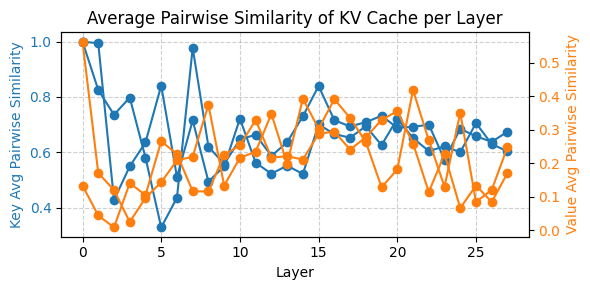

In [9]:
fig, ax1 = plt.subplots(figsize=(6, 3))

color1 = 'tab:blue'
ax1.set_xlabel("Layer")
ax1.set_ylabel("Key Avg Pairwise Similarity", color=color1)
ax1.plot(np.array(key_sims).mean(axis=0), marker='o', color=color1, label='Key Similarity')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()  # 生成第二个y轴
color2 = 'tab:orange'
ax2.set_ylabel("Value Avg Pairwise Similarity", color=color2)
ax2.plot(np.array(value_sims).mean(axis=0), marker='o', color=color2, label='Value Similarity')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Average Pairwise Similarity of KV Cache per Layer")
fig.tight_layout()
ax1.grid(True,  linestyle='--', alpha=0.6)
plt.show()

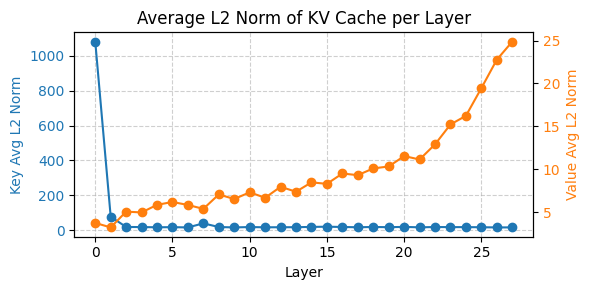

In [10]:

fig, ax1 = plt.subplots(figsize=(6, 3))
start_layer=0
color1 = 'tab:blue'
ax1.set_xlabel("Layer")
ax1.set_ylabel("Key Avg L2 Norm", color=color1)
ax1.plot(np.array(key_norms).mean(axis=0)[start_layer:], marker='o', color=color1, label='Key Norm')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()  # 生成第二个y轴
color2 = 'tab:orange'
ax2.set_ylabel("Value Avg L2 Norm", color=color2)
ax2.plot(np.array(value_norms).mean(axis=0)[start_layer:], marker='o', color=color2, label='Value Norm')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Average L2 Norm of KV Cache per Layer")
fig.tight_layout()
ax1.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Sparsity

In [11]:
layer_batch = 7
sparsity_list = []
for i in tqdm(range(10)):
    input_text = data[i]["prompt"] + data[i]["output"]
    inputs = tokenizer(input_text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(
            **inputs, output_attentions=True, return_dict=True  # 返回注意力得分
        )
        attn_scores = outputs.attentions

    sparsity = []
    for l in range(0, len(attn_scores), layer_batch):
        if l + layer_batch > len(attn_scores):
            last_layer = len(attn_scores)
        else:
            last_layer = l + layer_batch
        attn_stack = torch.stack(
            attn_scores[l:last_layer], dim=0
        )  # (num_layers, batch, head, seq_len, seq_len)
        num_layers, batch, head, seq_len, _ = attn_stack.shape
        max_per_row = attn_stack.max(dim=-1, keepdim=True).values
        threshold_per_row = 1e-2 * max_per_row
        non_zero = (attn_stack >= threshold_per_row)
        num_non_zero = non_zero.sum(dim=-1).float()
        num_elements=torch.arange(1,1+seq_len).float().unsqueeze(0).unsqueeze(0).unsqueeze(0)
        num_elements=num_elements.to(device)
        sparsity_t = 1 - num_non_zero / num_elements
        sparsity_t=sparsity_t.mean(dim=(1,2,3))
        sparsity.extend(sparsity_t.cpu().tolist())
    sparsity_list.append(sparsity)

100%|██████████| 10/10 [00:04<00:00,  2.35it/s]


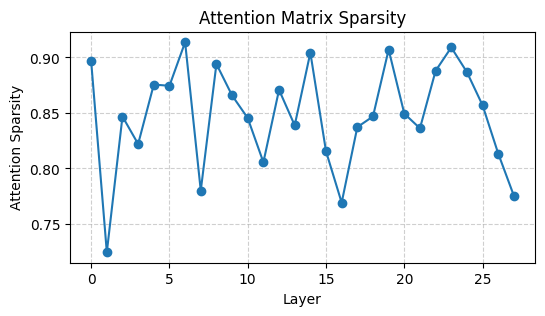

In [12]:
# 可视化稀疏度
plt.figure(figsize=(6,3))
plt.plot(np.array(sparsity_list).mean(axis=0), marker='o')
plt.xlabel("Layer")
plt.ylabel("Attention Sparsity")
plt.title(f"Attention Matrix Sparsity")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Attention 

In [6]:
import matplotlib.colors as mcolors

sample_idx = 0
input_text = data[sample_idx]["prompt"] + data[sample_idx]["output"]
inputs = tokenizer(input_text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(
        **inputs, output_attentions=True, return_dict=True
    )
    attn_scores = outputs.attentions  # list of (batch, head, seq_len, seq_len)


`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


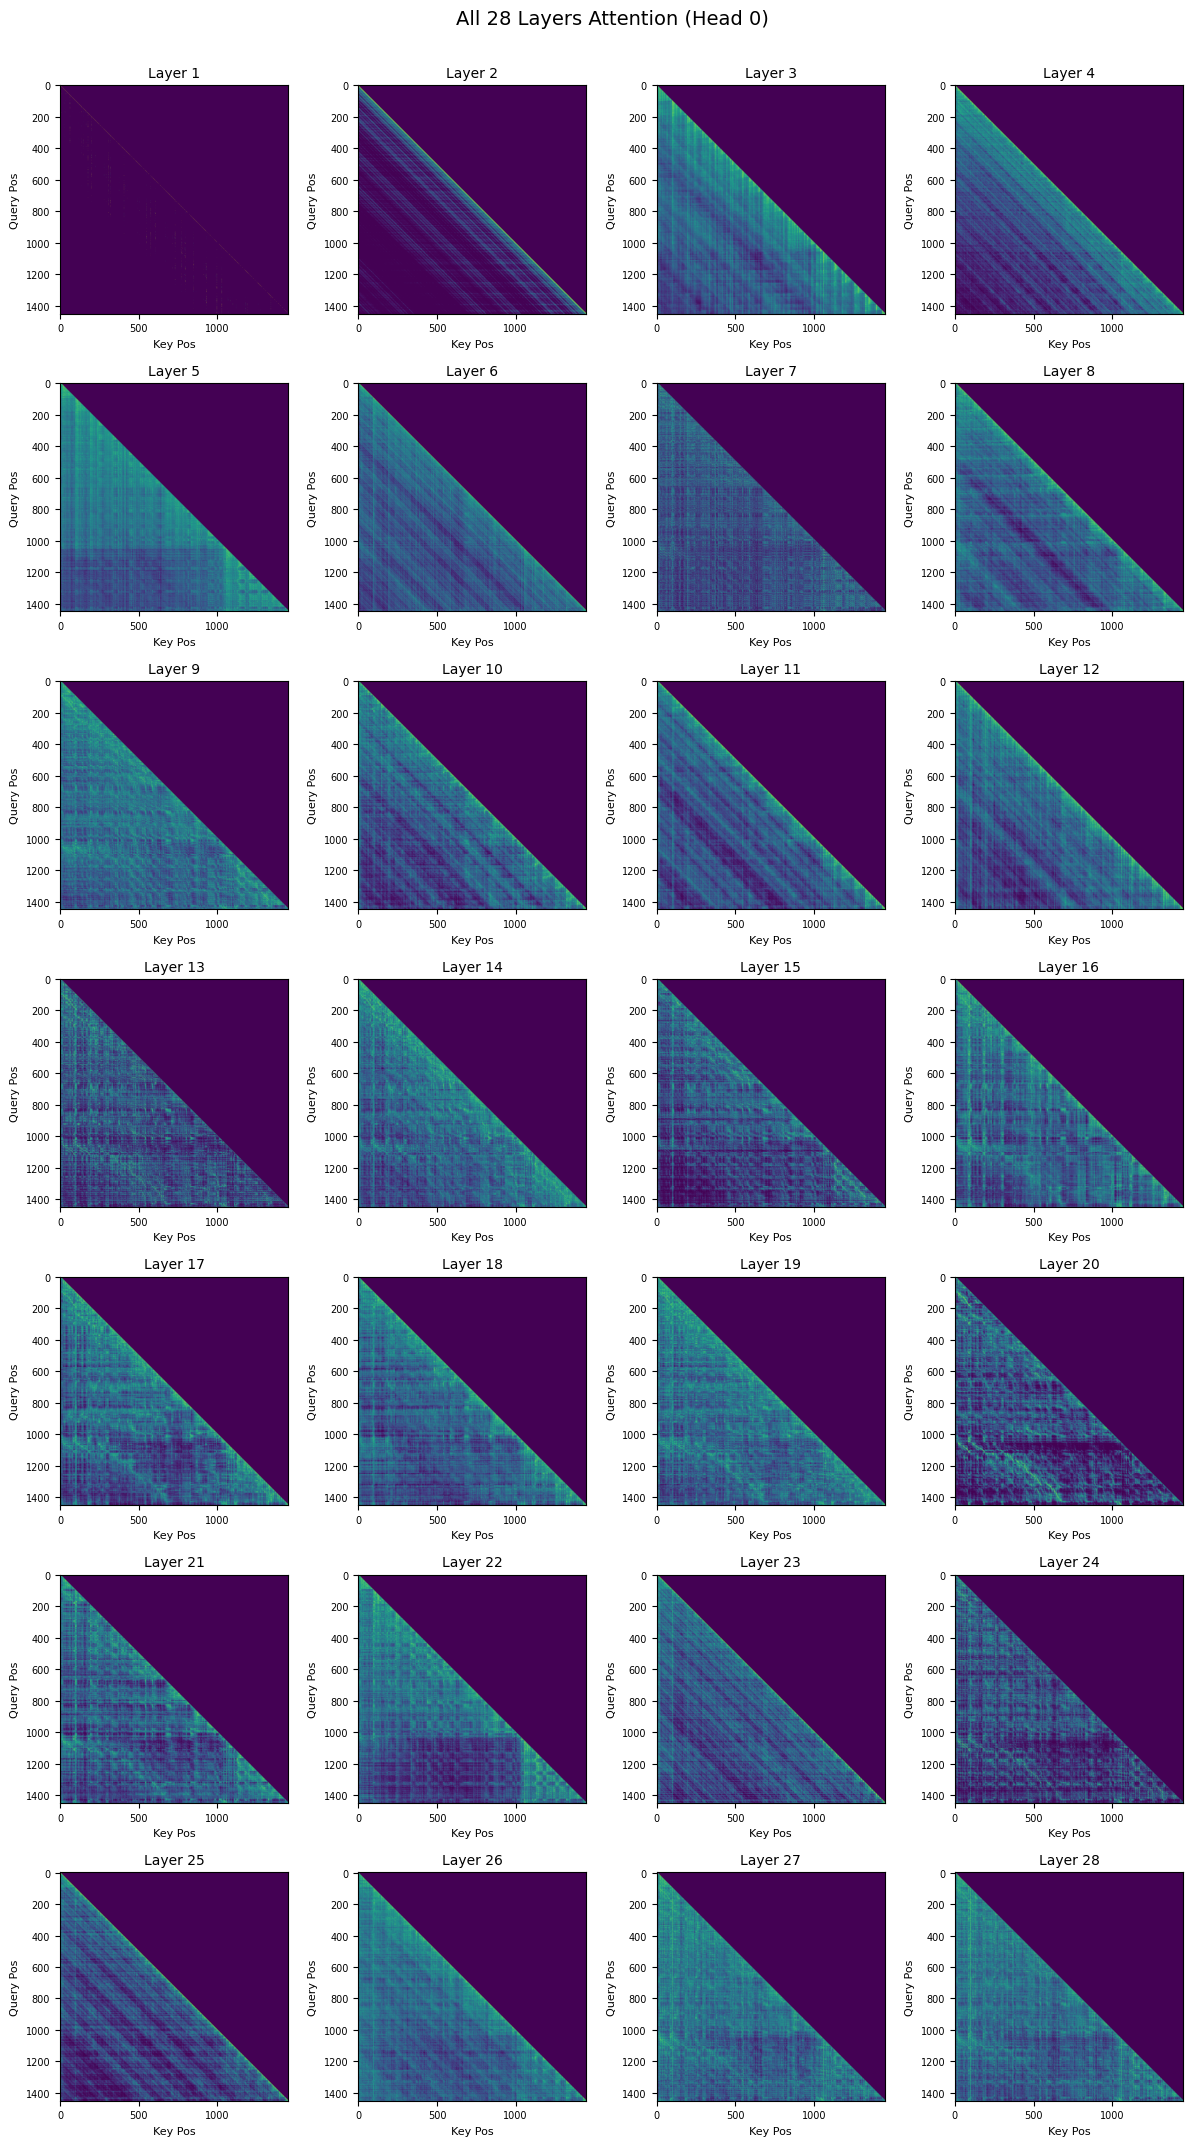

In [7]:
# 总共28层，全部画出来，图片为7行4列
num_layers = len(attn_scores)
rows, cols = 7, 4
plt.figure(figsize=(3.1 * cols, 3 * rows))
for l in range(num_layers):
    plt.subplot(rows, cols, l + 1)
    attn = attn_scores[l][0, 1].detach().cpu().numpy()
    plt.imshow(attn + 1e-6, cmap='viridis', norm=mcolors.LogNorm(vmin=1e-6, vmax=1))
    plt.title(f"Layer {l+1}", fontsize=10)
    plt.xlabel("Key Pos", fontsize=8)
    plt.ylabel("Query Pos", fontsize=8)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
# plt.colorbar(fraction=0.025, pad=0.02)
plt.suptitle("All 28 Layers Attention (Head 0)", y=1.02, fontsize=14)
plt.show()

# Compress Sparsity

In [49]:
import numpy as np


In [1]:
import numpy as np
file='./outputs/amc23_dsqwen7b_rkv_info.npy'

if file.endswith('.json'):
    with open(file,'r') as f:
        data=json.load(f)
    data['scores']=[np.array(d) for d in data['scores']]
    data['pos_ids']=[np.array(d) for d in data['pos_ids']]
    data=np.array(data,dtype=object)
elif file.endswith('.npy'):
    data=np.load(file,allow_pickle=True)




In [7]:
for d in data.item()['pos_ids']:
    print(d.shape)

(28, 32, 2, 534)
(28, 32, 2, 616)
(28, 16, 2, 533)


In [19]:
import matplotlib.pyplot as plt

all_values = []
for d in data.item()['pos_ids']:
    max_v = d.max(axis=-1, keepdims=True)
    d_norm = d / max_v
    all_values.append(d_norm.flatten())
all_values = np.concatenate(all_values)



In [20]:
all_values=all_values[:10000]

<Figure size 600x400 with 0 Axes>

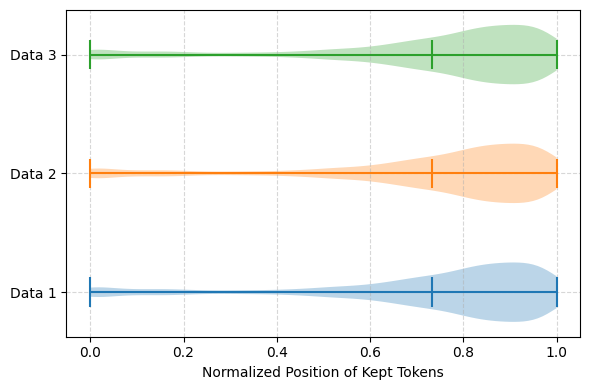

In [23]:
scores_list=[all_values,all_values,all_values]


plt.figure(figsize=(6, 4))

# 不同的数据不同的位置
positions = [1, 2, 3]  # 假设有3组数据，分别放在y轴的1、2、3位置
plt.figure(figsize=(6, 4))
for i, scores in enumerate(scores_list):
    plt.violinplot(scores, positions=[positions[i]], showmeans=True, vert=False)
plt.xlabel("Normalized Position of Kept Tokens")
plt.yticks(positions, [f'Data {i+1}' for i in range(len(scores_list))])
plt.grid(alpha=0.5,linestyle='--')
plt.tight_layout()
plt.show()

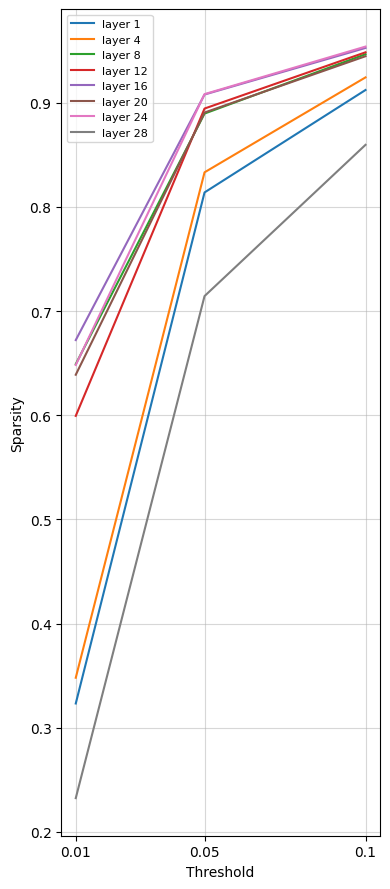

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
plt.xticks(rates, [str(r) for r in rates]) 
plt.plot(rates, sps[0], label=f'layer 1')
for i in range(3, sps.shape[0], 4):
    plt.plot(rates, sps[i], label=f'layer {i+1}')

plt.legend(fontsize=8)
plt.grid(alpha=0.5)
plt.xlabel("Threshold")
plt.ylabel("Sparsity")
plt.tight_layout()
plt.show()


In [48]:
import numpy as np

data=np.load('npdata.npy',allow_pickle=True)
print(data)



{'scores': [array([[[[6.14654830e-02, 8.55028332e-01, 5.82751044e-01, ...,
          6.20608489e-01, 2.34489536e-01, 3.35616257e-01],
         [3.04621350e-01, 9.18175392e-01, 1.46313948e-01, ...,
          4.48034058e-01, 1.40766995e-01, 5.06977781e-01]],

        [[9.91180517e-01, 4.69394620e-01, 5.51193180e-01, ...,
          6.48772151e-01, 5.31490580e-01, 8.16361020e-01],
         [5.82288302e-01, 3.64274774e-01, 7.27963869e-01, ...,
          6.94913296e-01, 6.52806121e-01, 9.17518888e-02]],

        [[8.08753738e-01, 6.22672639e-01, 7.66142607e-01, ...,
          6.82026165e-02, 4.84935333e-01, 5.14715171e-01],
         [5.88207269e-01, 6.89315515e-01, 7.78881385e-01, ...,
          8.67106929e-01, 9.25099701e-01, 8.57268067e-01]],

        [[4.43777778e-01, 5.32951105e-01, 5.28890272e-01, ...,
          8.84698295e-01, 9.38018367e-01, 2.93031803e-01],
         [1.79075693e-01, 1.28244681e-01, 7.50024911e-01, ...,
          3.72409353e-01, 8.65341355e-01, 3.20744758e-01]]],


  

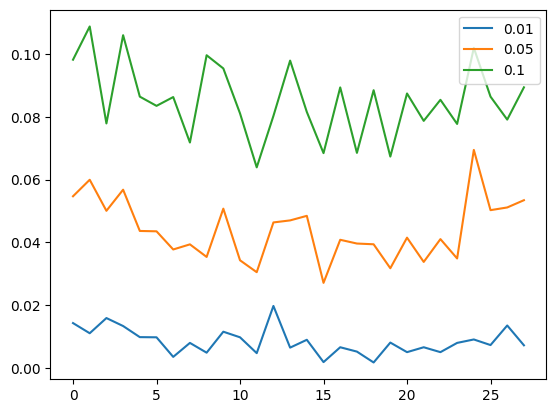

In [39]:


plt.plot(reduced_spars[0],label='0.01')
plt.plot(reduced_spars[1],label='0.05')
plt.plot(reduced_spars[2],label='0.1')
plt.legend()
plt.show()
